In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit
from numba import prange
import time

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation

print("Fin")

Fin


In [2]:
## Independent parameters (free to edit)

Na = 0.5 # Units: M 
valence = 4
duration = 1000 * 10**5 # In timesteps of dt
gridpoints = 512 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 6E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2= 1.0 / (dx * dx)

#Establishes constants
K = 1.0E6 # Units: nm^5 
M = 1 # Units: (nm s)^-1
vb = 1.66 # Units: nm^3
kB = 1.314E-23*0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
dHa = -42000 # Units: cal/mol 
dS1 = 1.84*np.log(Na) # Units: cal/mol K
dS0 = -120 # Units: cal/mol K at 1M NaCl
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 #Number of saved values

B2 = 1878 # Units: nm^3

temperatures = np.arange(290.15,310.15, 0.5)

print("Fin")

Fin


In [3]:
# Initializes array of density values, one row per temperature
np.random.seed(7) # Opens a random number generator instance, seed 7
n_temperatures = len(temperatures)  # temperatures = array of T values to sweep over

# Creates rho values around the mean with slight randomness, one row per temperature
rho_all = np.zeros((n_temperatures, gridpoints))
for i in range(n_temperatures):
    rho_all[i] = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=gridpoints))
rho_all = np.maximum(rho_all, 1.E-10)  # Prevents negative densities
initial_mass = np.sum(rho_all, axis=1)

# Da varies with temperature; vb, dHa, dS0, dS1, mol, kB are fixed constants
Da_all = vb * np.exp(-(dHa - temperatures * (dS0 + dS1)) / (mol * kB * temperatures))

@jit(nopython=True, parallel = False, cache = False)
def laplacian_1d(function_array):
    """
    Computes the 1D Laplacian of a function, given an array representing that function
    """
    return (np.roll(function_array, -1) - 2*function_array + np.roll(function_array, 1)) * inv_dx2
    # Note: I used 'roll' so it would have periodic boundary conditions






@jit(nopython=True, parallel = False, cache = False) # Converts the given function into machine code (optimization)
def compute_step_single_AAAA(rho, Da, Db):
    # Total chemical potential (with floored rho, Xa)
    beta_mu_total = (2.0 * B2 * rho + np.log(rho) + #beta mu_ref
                    valence * np.log((-1 + np.sqrt(1 + 4 * 4*rho*Da)) / (2 * 4*rho*Da)) - #beta mu_b
                    K * (np.roll(rho, -1) - 2.0 * rho + np.roll(rho, 1)) * inv_dx2) #beta mu_int
    # Finds the 1D Laplacian of beta mu total
    laplacian_1d_mu = laplacian_1d(beta_mu_total)
    # Updates the density explicitly: rho(t+dt) = rho(t) + dt * M laplacian (beta mu_total)
    return  dt * M * laplacian_1d_mu


@jit(nopython=True, parallel = False, cache = False) # Converts the given function into machine code (optimization)
def compute_step_single_ABBB(rho, Da, Db):
    # Arm-type bonding concentrations: 1 A-arm and 3 B-arms per nanostar, no AAAA species present
    Ca = rho * Da          
    Cb = 3.0 * rho * Db    
    Xa = (-1.0 + np.sqrt(1.0 + 4.0 * Ca)) / (2.0 * Ca)  # unbonded fraction, A arms
    Xb = (-1.0 + np.sqrt(1.0 + 4.0 * Cb)) / (2.0 * Cb)  # unbonded fraction, B arms

    # Total chemical potential (with floored rho, Xa, Xb)
    beta_mu_total = (2.0 * B2 * rho + np.log(rho) +               #beta mu_ref
                    np.log(Xa) + 3.0 * np.log(Xb) -                #beta mu_b (1 A-arm + 3 B-arms)
                    K * (np.roll(rho, -1) - 2.0 * rho + np.roll(rho, 1)) * inv_dx2) #beta mu_int
    # Finds the 1D Laplacian of beta mu total
    laplacian_1d_mu = laplacian_1d(beta_mu_total)
    # Updates the density explicitly: rho(t+dt) = rho(t) + dt * M laplacian (beta mu_total)
    return  dt * M * laplacian_1d_mu



@jit(nopython=True, parallel = True, cache = False)
def apply_timestep_all(rho_all, Da_all):
    # Applies one timestep to every temperature row in parallel
    n_temperatures, gridpoints = rho_all.shape
    rho_out = np.zeros_like(rho_all)
    for i in prange(n_temperatures):
        rho = rho_all[i]
        Da = Da_all[i]
        rho_out[i] = rho + compute_step_single_ABBB(rho, Da, Da)
    return rho_out

log_dir = "sim_logs"
os.makedirs(log_dir, exist_ok=True)
progress_file = os.path.join(log_dir, "1D_phase_diagram_2d_progress.txt")

for step in range(duration):
    # Iterates to find new value of rho_all, all temperatures at once
    rho_all = apply_timestep_all(rho_all, Da_all)
    if step % save_interval == 0:
        rho_all = np.maximum(rho_all, floor)
        with open(progress_file, "w") as f:
            f.write(f"Progress: {step//save_interval} out of {duration//save_interval}\n")

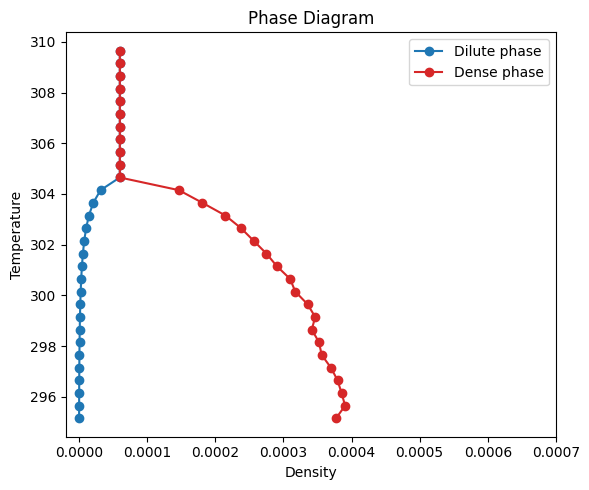

<Figure size 640x480 with 0 Axes>

In [5]:
# Extracts dilute/dense phase densities from the final state of each row
def extract_phase_densities(final_rho):
    dilute = np.min(final_rho)
    dense = np.max(final_rho)
    return dilute, dense

dilute_densities = np.zeros(n_temperatures)
dense_densities = np.zeros(n_temperatures)
for i in range(n_temperatures):
    dilute_densities[i], dense_densities[i] = extract_phase_densities(rho_all[i])
    
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(dilute_densities, temperatures, 'o-', color='tab:blue', label='Dilute phase')
ax.plot(dense_densities, temperatures, 'o-', color='tab:red', label='Dense phase')
ax.set_xlabel('Density')
ax.set_ylabel('Temperature')
ax.set_title('Phase Diagram')
plt.xticks([0, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007])
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("phase_diagram.png")